# Bogotá Property Price Predictor
## Notebook 2 — Exploratory Data Analysis

> *This notebook answers one question: what does the Bogotá real estate market actually look like?*

In Notebook 1, we transformed 5,002 raw scraped listings into a clean, structured dataset. Now we investigate that data visually and statistically — not to build models yet, but to develop the domain understanding that drives smart modeling decisions.

Every chart in this notebook is tied to a modeling implication. The EDA Summary at the end maps each finding directly to a decision implemented in Notebook 3.

**This notebook covers:**
1. Price distribution — the shape of the target variable
2. Price by property type — which market segments command higher prices
3. Price by neighborhood — the geography of value in Bogotá
4. Area vs price — verifying and quantifying the strongest numeric predictor
5. Bedrooms, bathrooms & parking — the role of unit characteristics
6. Correlation heatmap — the full picture of feature relationships

| | |
|---|---|
| **Input** | `../data/cleaned_properati.csv` |
| **Previous** | Notebook 1 — Data Collection & Cleaning |
| **Next** | Notebook 3 — Modeling & Prediction |


---
## 📦 Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

In [2]:
df = pd.read_csv("../data/cleaned_properati.csv")

# Restore original-scale columns for readable labels in charts
df["price_COP"] = np.exp(df["log_price"])
df["area_m2"]  = np.exp(df["log_area"])

print(f"{df.shape[0]:,} listings · {df.shape[1]} features")
df.head(3)

4,509 listings · 9 features


,location,type,bedrooms,bathrooms,parking,log_area,log_price,price_COP,area_m2
0,Fontibón,Local,3,2.0,0,5.493061,20.422161,7.400000e+08,243.0
1,Puente Aranda,Apartamento,3,4.5,1,5.323010,21.128731,1.500000e+09,205.0
2,Puente Aranda,Casa,4,4.0,1,5.624018,21.639557,2.500000e+09,277.0


---
## 1. Price Distribution

The target variable — property price — is the first thing to understand. A model predicts the target, so the target's shape directly determines how we should treat it.

We compare the raw price distribution (in billions of COP) against the log-transformed version. The goal: decide which scale to use as the model target.


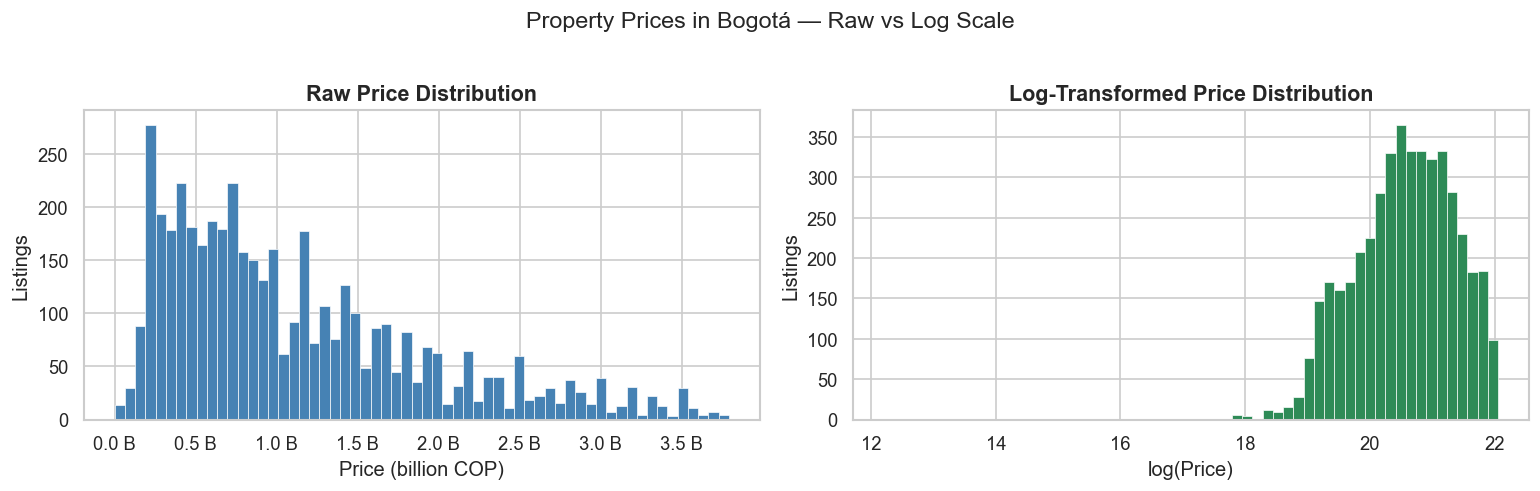

Median price : 0.89 B COP
Mean price   : 1.12 B COP


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Raw price
axes[0].hist(df["price_COP"] / 1e9, bins=60, color="steelblue", edgecolor="white", linewidth=0.4)
axes[0].set_title("Raw Price Distribution", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Price (billion COP)")
axes[0].set_ylabel("Listings")
axes[0].xaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f B"))

# Log price
axes[1].hist(df["log_price"], bins=60, color="seagreen", edgecolor="white", linewidth=0.4)
axes[1].set_title("Log-Transformed Price Distribution", fontsize=13, fontweight="bold")
axes[1].set_xlabel("log(Price)")
axes[1].set_ylabel("Listings")

plt.suptitle("Property Prices in Bogotá — Raw vs Log Scale", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

median_price = df["price_COP"].median() / 1e9
mean_price   = df["price_COP"].mean()   / 1e9
print(f"Median price : {median_price:.2f} B COP")
print(f"Mean price   : {mean_price:.2f} B COP")

**Finding:** Raw prices are heavily right-skewed — a small number of high-value properties
above 2.5B COP pull the mean above the median. The bulk of listings cluster below 1.5B
COP, which is typical of urban real estate markets where a thin premium segment coexists
with a large mid-market.

**Modeling implication:** Log-transforming price produces a near-normal distribution
centered around log(Price) ≈ 20.8–21.0 (roughly 0.9–1.3 billion COP). The model will
be trained to predict `log_price` and results will be exponentiated back to COP for
interpretation. This choice reduces the outsized influence of extreme values on the
loss function.

---
## 2. Price by Property Type

Bogotá's listing base includes five distinct property types: apartments, houses, offices, commercial spaces, and studio apartments. Before modeling all of them together, we need to know whether they occupy different price territories — or the same one.


C:\Users\yeyis\AppData\Local\Temp\ipykernel_10768\1113413538.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


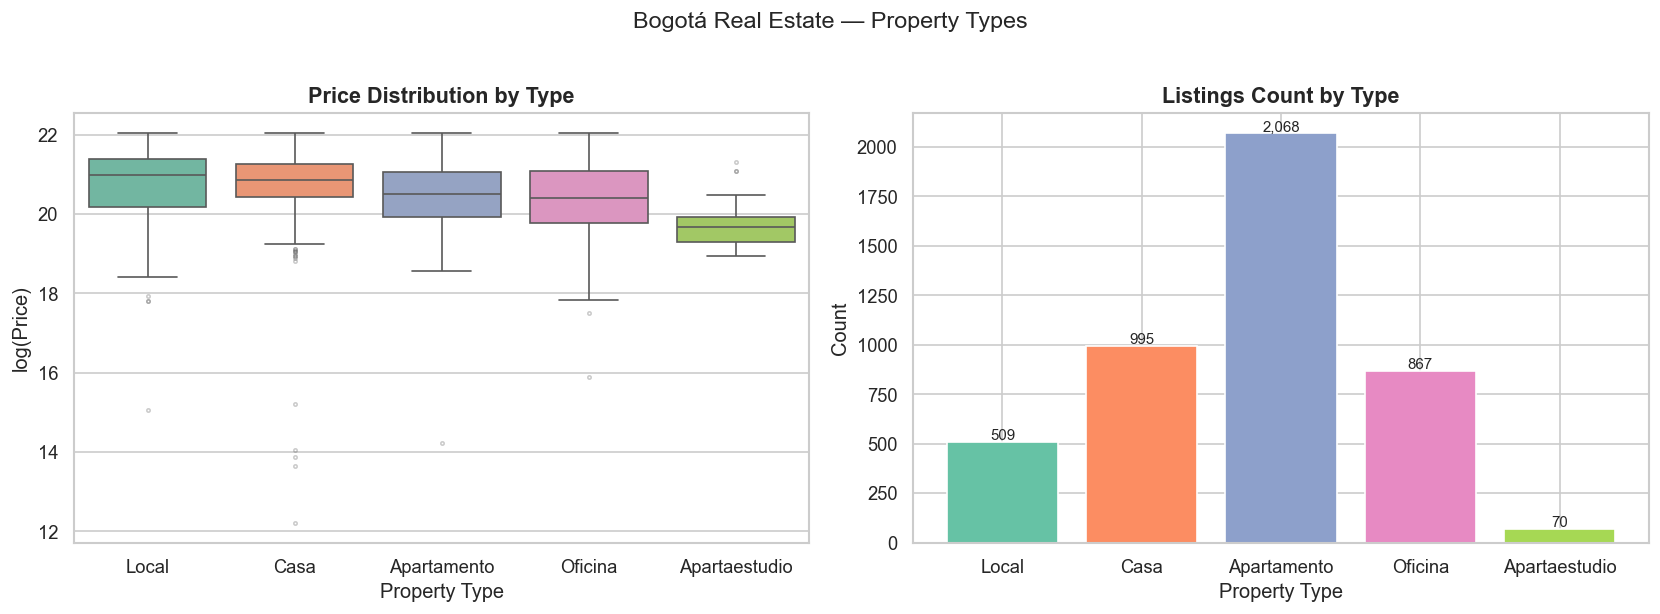

In [4]:
type_order = (
    df.groupby("type")["price_COP"]
    .median()
    .sort_values(ascending=False)
    .index
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot — spread and median
sns.boxplot(
    data=df, x="type", y="log_price",
    order=type_order, palette="Set2",
    flierprops={"marker": "o", "markersize": 2, "alpha": 0.3},
    ax=axes[0]
)
axes[0].set_title("Price Distribution by Type", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Property Type")
axes[0].set_ylabel("log(Price)")

# Count bar — how many listings per type
count_data = df["type"].value_counts().reindex(type_order)
axes[1].bar(count_data.index, count_data.values, color=sns.color_palette("Set2", len(type_order)))
axes[1].set_title("Listings Count by Type", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Property Type")
axes[1].set_ylabel("Count")
for i, v in enumerate(count_data.values):
    axes[1].text(i, v + 10, f"{v:,}", ha="center", fontsize=9)

plt.suptitle("Bogotá Real Estate — Property Types", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Finding:** Commercial spaces (`Local`) command the highest median log(Price), while
`Casa`, `Apartamento`, and `Oficina` cluster at similar median price levels. Studio
apartments (`Apartaestudio`) sit clearly at the lower end of the price range and
represent a very small share of listings (n = 70). `Apartamento` dominates the dataset
(2,068 listings), making it the backbone of Bogotá's residential market.

**Modeling implication:** Commercial types (`Local`, `Oficina`) follow a different pricing
logic — their value depends on foot traffic and commercial zoning, not on bedrooms or
bathrooms. Including them in a residential price model would add noise. In Notebook 3,
we filter the training data to residential types only: `Apartamento`, `Casa`, and
`Apartaestudio`, while noting that the small Apartaestudio sample may limit its
representativeness.


---
## 3. Price by Neighborhood

In real estate, location is everything. This section quantifies what that means in Bogotá — how much does the choice of neighborhood affect price, and which areas define the top and bottom of the market?

We show the 15 most expensive and 15 most affordable neighborhoods among those with at least 10 listings. Neighborhoods with fewer listings are excluded to avoid median estimates based on one or two properties.


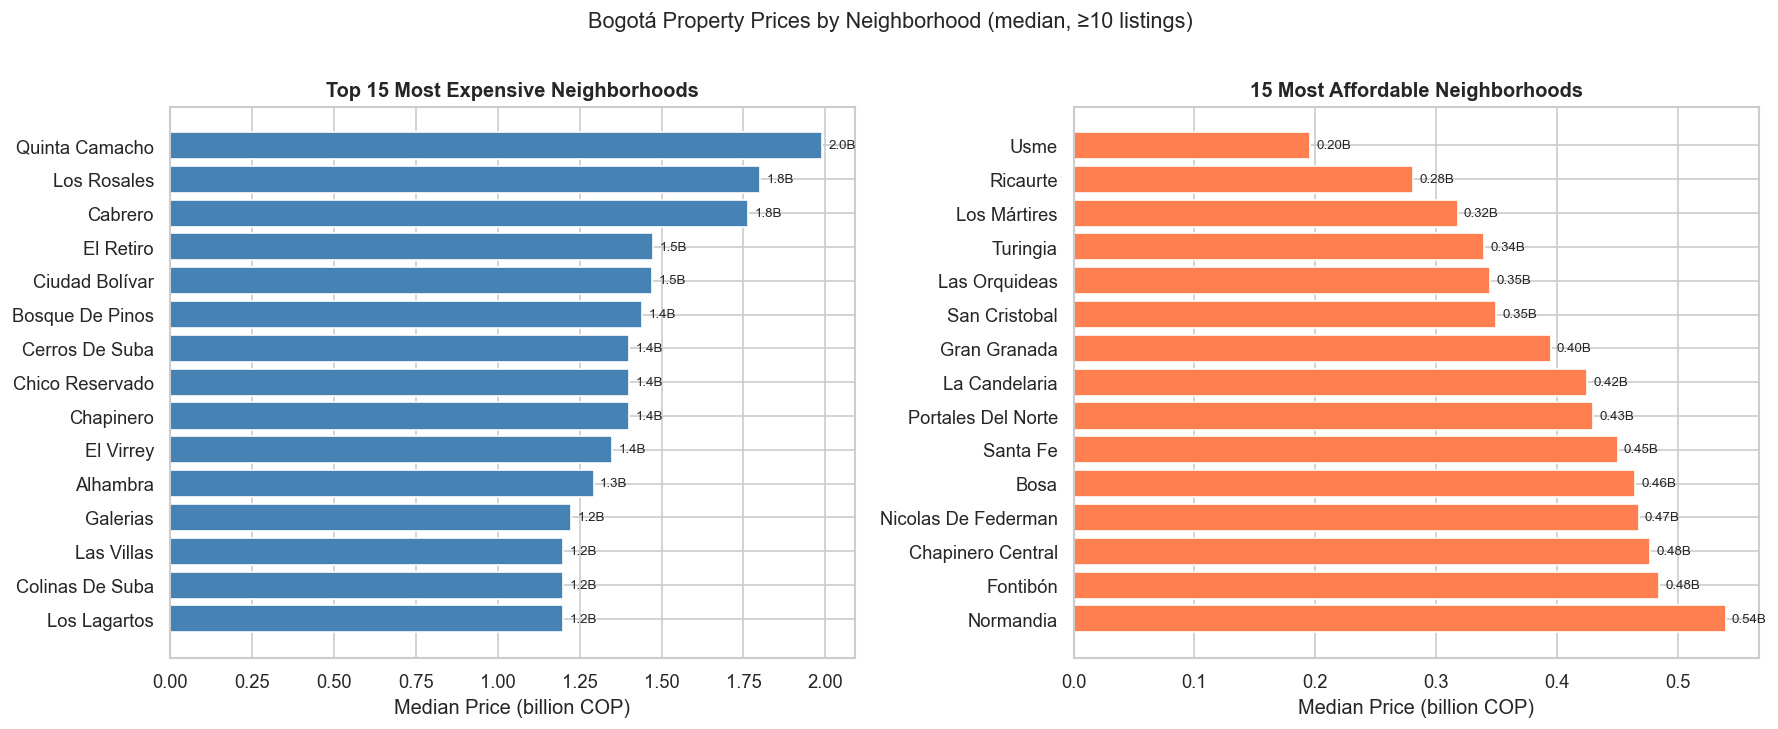

In [5]:
location_stats = (
    df.groupby("location")["price_COP"]
    .agg(["median", "count"])
    .query("count >= 10")
    .sort_values("median", ascending=False)
)

top15    = location_stats.head(15)
bottom15 = location_stats.tail(15).sort_values("median")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Top 15
axes[0].barh(top15.index, top15["median"] / 1e9, color="steelblue")
axes[0].set_title("Top 15 Most Expensive Neighborhoods", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Median Price (billion COP)")
axes[0].invert_yaxis()
for i, (idx, row) in enumerate(top15.iterrows()):
    axes[0].text(row["median"] / 1e9 + 0.02, i, f"{row['median']/1e9:.1f}B", va="center", fontsize=8)

# Bottom 15
axes[1].barh(bottom15.index, bottom15["median"] / 1e9, color="coral")
axes[1].set_title("15 Most Affordable Neighborhoods", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Median Price (billion COP)")
axes[1].invert_yaxis()
for i, (idx, row) in enumerate(bottom15.iterrows()):
    axes[1].text(row["median"] / 1e9 + 0.005, i, f"{row['median']/1e9:.2f}B", va="center", fontsize=8)

plt.suptitle("Bogotá Property Prices by Neighborhood (median, ≥10 listings)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Finding:** North-zone neighborhoods (El Retiro, Chicó, Los Rosales) anchor the luxury segment with medians above 1.4 billion COP. South and peripheral zones (Usme, Ricaurte, San Cristobal) are 5–10× more affordable — medians under 400 million COP. Bogotá's north-south socioeconomic divide is stark and consistent.

**Modeling implication:** Location is the single most important categorical feature and must be encoded carefully. Simple one-hot encoding across 40+ neighborhoods creates sparse, high-dimensional features. **Target encoding** — replacing each neighborhood with its mean log-price — captures the price signal directly while avoiding the dimensionality problem. Neighborhoods with fewer than 15 listings are grouped into an `"Other"` category to prevent unreliable estimates. A macro-zone feature (`Norte`, `Sur`, etc.) provides a fallback signal for rare neighborhoods.


---
## 4. Area vs Price

Area is the most intuitive driver of property value — larger properties should cost more. We verify this relationship, quantify its strength, and check whether it holds consistently across property types.


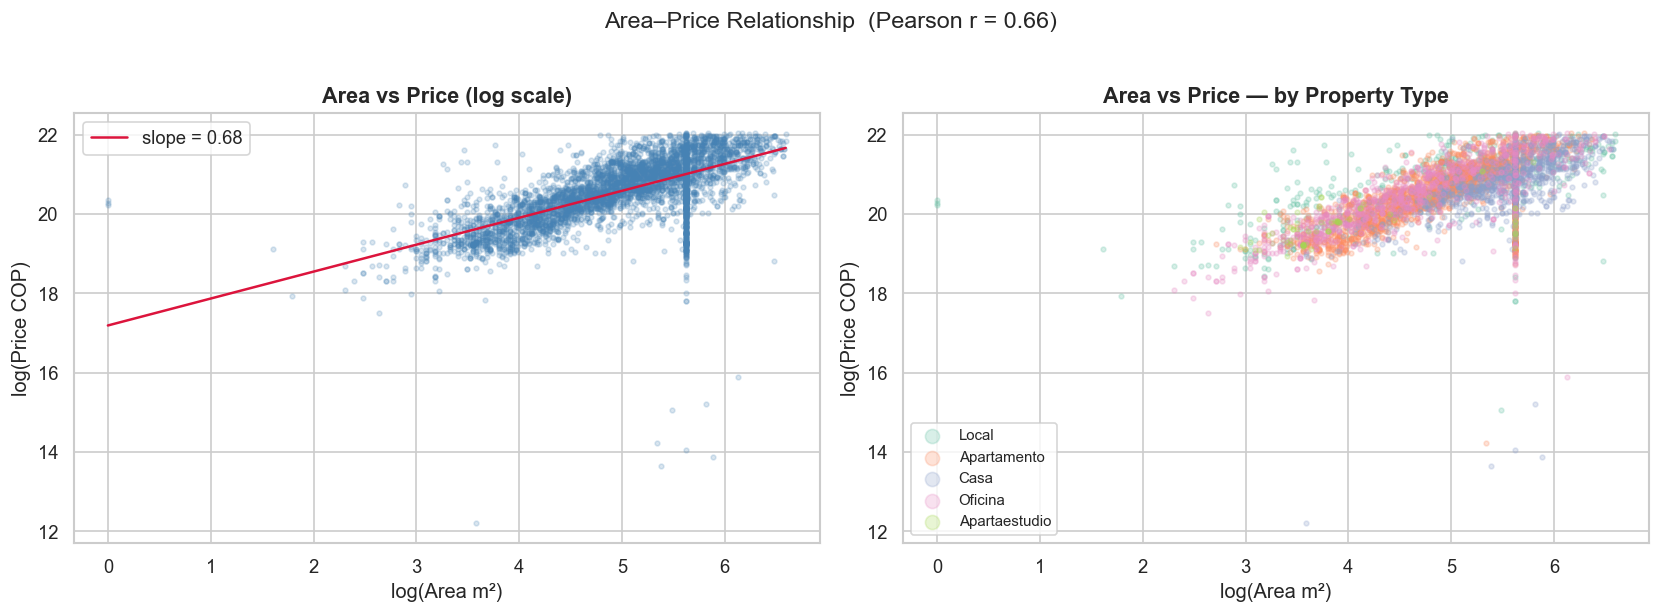

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall scatter (log scale)
axes[0].scatter(
    df["log_area"], df["log_price"],
    alpha=0.2, s=8, color="steelblue"
)
# Trend line
m, b = np.polyfit(df["log_area"], df["log_price"], 1)
x_range = np.linspace(df["log_area"].min(), df["log_area"].max(), 100)
axes[0].plot(x_range, m * x_range + b, color="crimson", linewidth=1.5, label=f"slope = {m:.2f}")
axes[0].set_title("Area vs Price (log scale)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("log(Area m²)")
axes[0].set_ylabel("log(Price COP)")
axes[0].legend()

# By type
palette = sns.color_palette("Set2", df["type"].nunique())
for i, t in enumerate(df["type"].unique()):
    subset = df[df["type"] == t]
    axes[1].scatter(subset["log_area"], subset["log_price"],
                    alpha=0.25, s=8, label=t, color=palette[i])
axes[1].set_title("Area vs Price — by Property Type", fontsize=13, fontweight="bold")
axes[1].set_xlabel("log(Area m²)")
axes[1].set_ylabel("log(Price COP)")
axes[1].legend(markerscale=3, fontsize=9)

corr = df[["log_area", "log_price"]].corr().iloc[0, 1]
plt.suptitle(f"Area–Price Relationship  (Pearson r = {corr:.2f})", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Finding:** `log_area` and `log_price` have a moderate-to-strong positive linear 
relationship (Pearson r = 0.66, slope = 0.68). This means a 1% increase in area is 
associated with approximately a 0.68% increase in price — area exhibits sub-linear 
returns, suggesting diminishing price gains per additional m² as properties grow larger. 
Offices and commercial spaces tend to cluster at larger areas relative to their price, 
reinforcing the case for separating them from the residential analysis.

**Modeling implication:** `log_area` will be the dominant numeric feature. The sub-linear 
slope (< 1) suggests that area alone does not fully capture price — other features such 
as location, bedroom/bathroom count, and property type likely explain the remaining 
variance, motivating the inclusion of categorical variables and interaction terms in 
Notebook 3.


---
## 5. Bedrooms, Bathrooms & Parking

Beyond area, three discrete counts characterize a residential property: bedrooms, bathrooms, and whether it has parking. We examine how each relates to price and whether the relationships are monotonic.


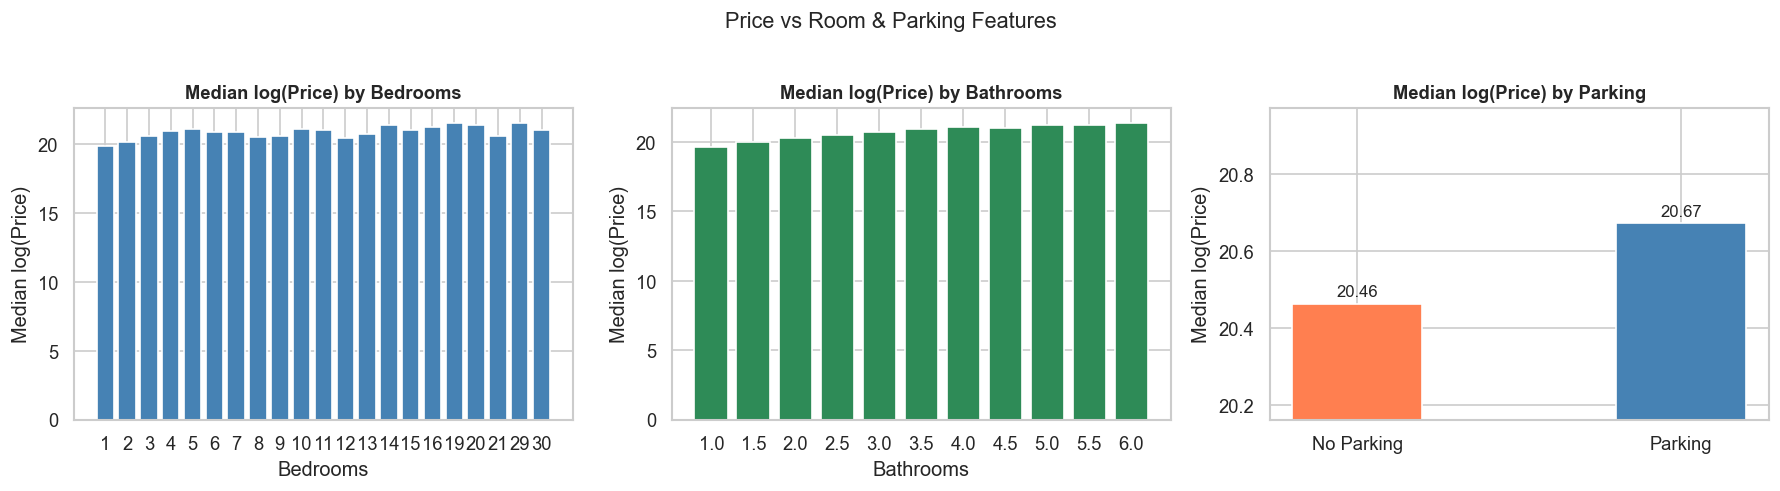

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Bedrooms
bedroom_price = df.groupby("bedrooms")["log_price"].median()
axes[0].bar(bedroom_price.index.astype(str), bedroom_price.values, color="steelblue")
axes[0].set_title("Median log(Price) by Bedrooms", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Bedrooms")
axes[0].set_ylabel("Median log(Price)")

# Bathrooms (cap at 6 for readability)
bath_data = df[df["bathrooms"] <= 6]
bath_price = bath_data.groupby("bathrooms")["log_price"].median()
axes[1].bar(bath_price.index.astype(str), bath_price.values, color="seagreen")
axes[1].set_title("Median log(Price) by Bathrooms", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Bathrooms")
axes[1].set_ylabel("Median log(Price)")

# Parking
parking_labels = ["No Parking", "Parking"]
parking_price  = df.groupby("parking")["log_price"].median()
bars = axes[2].bar(parking_labels, parking_price.values, color=["coral", "steelblue"], width=0.4)
for bar, val in zip(bars, parking_price.values):
    axes[2].text(bar.get_x() + bar.get_width() / 2, val + 0.02,
                 f"{val:.2f}", ha="center", fontsize=10)
axes[2].set_title("Median log(Price) by Parking", fontsize=11, fontweight="bold")
axes[2].set_ylabel("Median log(Price)")
axes[2].set_ylim(parking_price.min() - 0.3, parking_price.max() + 0.3)

plt.suptitle("Price vs Room & Parking Features", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Findings:**
- Bedrooms drive price up to a point — the relationship plateaus around 4–5 bedrooms,
  suggesting that very high bedroom counts stop adding proportional value.
- Bathrooms show a cleaner monotonic relationship with price. Bathrooms are a better
  proxy for overall unit quality and finish level than bedroom count.
- Parking adds a meaningful price premium — listings with parking show a median
  log(Price) of 20.67 vs 20.46 without parking, roughly a ~23% premium in original
  price scale.

**Modeling implication:** All three features are included. The bathroom-to-bedroom ratio
(`bath_per_bed`) and total room count (`total_rooms`) are added as engineered features
in Notebook 3, capturing the quality signal that raw counts miss.

---
## 6. Correlation Heatmap

With the individual relationships understood, we look at the full picture: how all numeric features relate to each other and to the target. High inter-feature correlations can signal multicollinearity; low correlation with the target can signal low predictive value.


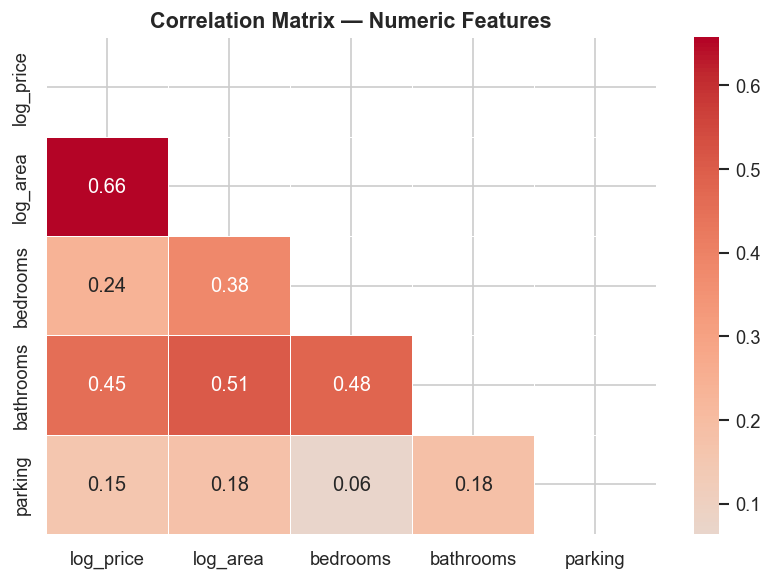

In [8]:
numeric_cols = ["log_price", "log_area", "bedrooms", "bathrooms", "parking"]
corr_matrix  = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt=".2f",
    cmap="coolwarm", center=0,
    linewidths=0.5, linecolor="white",
    ax=ax
)
ax.set_title("Correlation Matrix — Numeric Features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Findings:** `log_area` is the strongest individual predictor of `log_price` (r = 0.66).
Bathrooms correlate more strongly with price than bedrooms (0.45 vs 0.24) — confirming
the quality-proxy hypothesis. Parking has a weak positive correlation with price (r = 0.15).
Bedrooms and bathrooms are moderately correlated with each other (r = 0.48), expected
given that larger units tend to have more of both.

**Modeling implication:** None of the correlations are so high as to require feature
elimination. Polynomial interaction terms between area, bedrooms, and bathrooms are
likely to add signal rather than just redundancy.

---
## EDA Summary

Six sections of analysis produced six findings. Each finding maps to a concrete decision in Notebook 3. This table is the bridge between investigation and implementation.

| Finding | Modeling Decision |
|---|---|
| Prices are right-skewed | Predict `log_price`; exponentiate outputs for COP interpretation |
| `log_area` has the strongest linear correlation with price | Primary numeric feature; motivates area-based interaction terms |
| Location drives up to 10× price differences | Target-encode `location` and `zone`; group rare neighborhoods |
| Commercial types price differently from residential | Filter `Local` and `Oficina` from training data |
| Parking adds a consistent price premium | Include `parking` as a binary feature |
| Bathrooms outperform bedrooms as a price signal | Derive `bath_per_bed` ratio; include both raw features |


---
## What Comes Next — Notebook 3

The EDA has given us a map of the Bogotá market. Now we use it to build the prediction engine.

The findings above translate into the following concrete steps in Notebook 3:

1. **Filter residential listings only** — Apartamento, Casa, Apartaestudio
2. **Engineer new features** — bath-to-bed ratio, area-per-bedroom, total rooms, neighborhood count
3. **Target-encode location & zone** — replace category labels with mean log-price values
4. **Add polynomial interactions** — pairwise products of numeric features
5. **Tune Random Forest and XGBoost** — searching hyperparameters with R² as the scoring metric
6. **Stack both tuned models** — a Ridge meta-learner learns the optimal blend

**Target:** Predict residential property prices with RMSE < 400 million COP and R² ≥ 0.72 on the hold-out test set.

> Continue to **[Notebook 3 — Modeling & Prediction](03_modeling.ipynb)**
